#fMRI Data - Correlation Maps
Los mapas de correlacion se usan para identificar las zonas del cerebro que recibieron un estimulo en el lapso de tiempo. (analisis 2D)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
%matplotlib inline

In [3]:
# Import the data for slice 36
data = np.genfromtxt('slice_36.csv', delimiter=',')

In [4]:
print(data.shape) #64x64 puntos en 96 intervalos de tiempo

(4096, 96)


These are the main parameters of the fMRI scan and experimental desgin

In [6]:
block_design    = ['rest', 'stim']  #patron temporal del experimento, rest=reposo , stim = estimulo
block_size      = 6 #volumenes o tiempoints del bloque rest/stim
block_RT        = 7 #rt = repetition time - segundos entre una adquisición de volumen y la siguiente.
block_total     = 16 #bloques en total

block_length    = block_size*block_RT  #Duracion de un bloque
acq_num         = block_size*block_total  #numero total de volumenes en el experimento
data_time       = block_length*block_total  #tiempo total REAL en segundos
data_time_vol   = np.arange(acq_num)*block_RT #tiempo real del volumen(correccion eje X)

#dimensiones espaciales del corte
x_size = 64
y_size = 64

Reshape de data for back to a 3D array.  If we want to have a look at the data we an either look at a specific volume or we can average all volumes (time points) for each voxel to see the mean signal intensity, we need to end up with a 64x64 matrix.

In [7]:
data_ordered = data.reshape(x_size,y_size,acq_num)
print(data_ordered.shape)

(64, 64, 96)


##AVERAGE ALL VOLUMES
Promediamos los voxeles sobre todos los volumenes de tiempo (96). Obteniendo así una sola imagen donde la cada voxel representa la intensidad promedio de ese vóxel a lo largo de todo el experimento.

Un solo volumen de fMRI es ruidoso. Las imágenes funcionales tienen baja resolución y bastante ruido térmico/fisiológico (respiración, pulso, pequeños movimientos de cabeza). Al promediar los 96 volúmenes, ese ruido aleatorio tiende a cancelarse entre sí, mientras que la estructura anatómica real se refuerza.

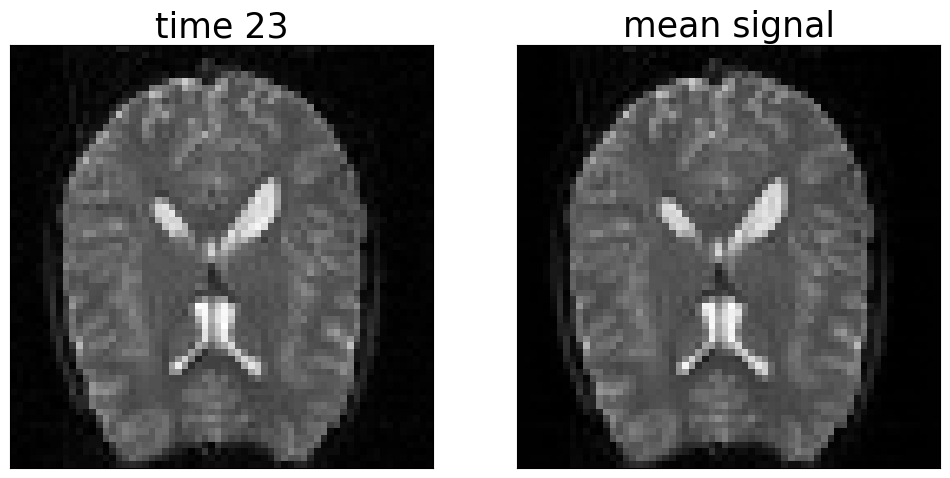

In [9]:
# Average all volumes
mean_data = data_ordered.mean(axis=2)

# Create plots
fig, ax = plt.subplots(1, 2,figsize=(12, 6))

# Plot volume number 23
ax[0].imshow(data_ordered[:, :, 23], cmap='gray')
ax[0].set_title('volume 23', fontsize=25)
ax[0].set_xticks([])
ax[0].set_yticks([])

# PLot mean signal intensities
ax[1].imshow(mean_data, cmap='gray')
ax[1].set_title('mean signal', fontsize=25)
ax[1].set_xticks([])
ax[1].set_yticks([])
plt.show()

#Cambio de un Voxel aleatorio en funcion del tiempo

In [10]:
# Select a random voxel by getting one random x- and y-coorinate
x_voxel = np.random.randint(64)
y_voxel = np.random.randint(64)

In [12]:
print(x_voxel, y_voxel)

54 57


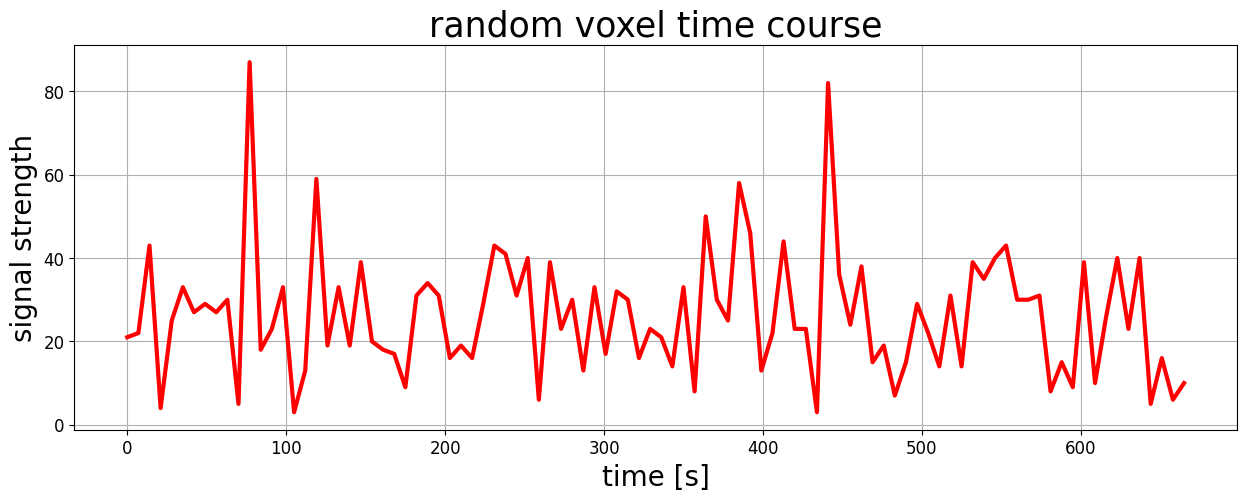

In [18]:
fig, ax = plt.subplots(1,1,figsize=(15, 5))
ax.plot(data_time_vol, data_ordered[x_voxel, y_voxel], c = "red" , lw=3)
ax.set_xlabel('time [s]', fontsize=20)  #tiempo real
ax.set_ylabel('signal strength', fontsize=20)
ax.set_title('random voxel time course', fontsize=25)
ax.tick_params(labelsize=12)
plt.grid()
plt.show()

OK this doesn't look like much. So lets think: How would you imagine the response to look like?
For now, lets keep things simple and just assume that without a stimulus the signal is at a baseline level and during the stimulation the signal goes up.
In the following we will create a "design matrix" which represents this hypothesis. The design matrix also contains a constant part which we will need later on to create our general linear model.

In [19]:
constant = np.ones(acq_num)   #array de 96 unos([1, 1, 1, ..., 1])

#bloques del patron temporal
rest     = np.zeros(block_size)
stim     = np.ones(block_size)
block    = np.concatenate((rest, stim), axis=0)


predicted_response = np.tile(block, int(block_total/2)) #repite un array completo n veces seguidas

design_matrix = np.array((constant, predicted_response))

In [23]:
design_matrix

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0.,
        0., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 1., 1.,
        1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.,
        0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0.,
        0., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 1., 1.,
        1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.]])

- **constant** tiene un propósito estadístico concreto: en un modelo lineal, el término constante captura el nivel base de la señal.
- **predicted_response** resume la hipótesis: "la señal debería estar en 0 durante el reposo y saltar a 1 durante el estímulo". es un modelo de bloques cuadrados, lo más simple posible.
- **desing_matrix** Junta los dos vectores (constant y predicted_response, cada uno de 96 elementos) en un único array 2D de forma (2, 96), dos "filas", cada una siendo uno de los predictores del modelo. Esta es la estructura de una matriz de diseño en el sentido estadístico del GLM: cada fila es un predictor, cada columna es un timepoint.

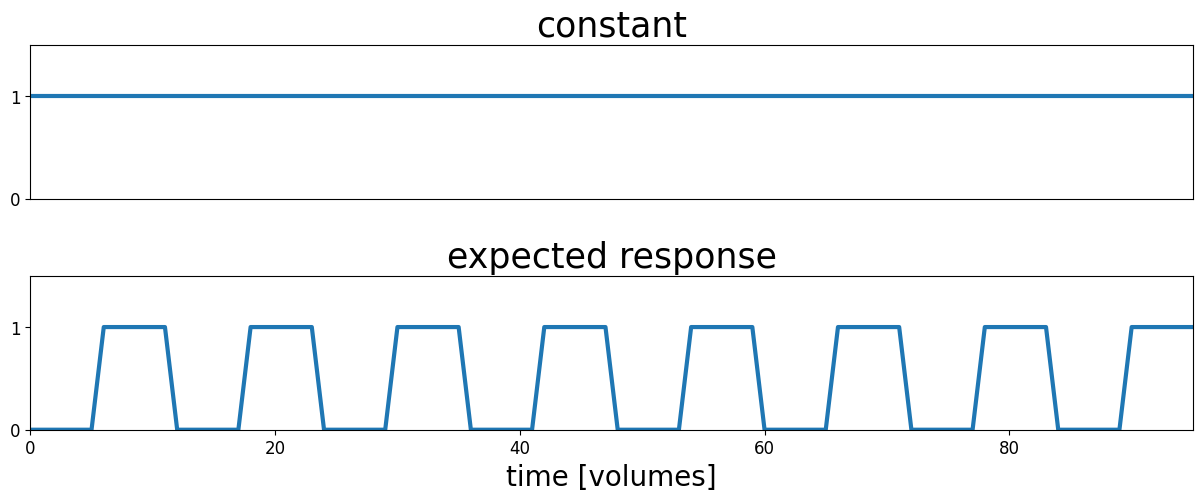

In [20]:
fig, ax = plt.subplots(2,1, figsize=(15, 5))
ax[0].plot(design_matrix[0], lw=3)
ax[0].set_xlim(0, acq_num-1)
ax[0].set_ylim(0, 1.5)
ax[0].set_title('constant', fontsize=25)
ax[0].set_xticks([])
ax[0].set_yticks([0,1])
ax[0].tick_params(labelsize=12)
ax[0].tick_params(labelsize=12)

ax[1].plot(design_matrix[1], lw=3)
ax[1].set_xlim(0, acq_num-1)
ax[1].set_ylim(0, 1.5)
ax[1].set_title('expected response', fontsize=25)
ax[1].set_yticks([0,1])
ax[1].set_xlabel('time [volumes]', fontsize=20)
ax[1].tick_params(labelsize=12)
ax[1].tick_params(labelsize=12)

fig.subplots_adjust(wspace=0, hspace=0.5)
plt.show()

La **Matriz de Diseño** contiene el diseño del experimento: la estructura de cuándo pasó cada cosa (cuándo hubo estímulo, cuándo no), definida por el investigador antes de mirar siquiera los datos reales. Es la hipótesis escrita en forma de números, lista para comparar contra lo que el experimento, en este caso el cerebro, realmente hizo.

##General Linear Model (GML)
Es método estadístico que modela una señal observada como una combinación lineal de predictores conocidos más error:
señal_observada = β₁·predictor₁ + β₂·predictor₂ + ... + error

>>"¿Puedo explicar esta señal que observé, como una combinación de ciertos factores que yo creo que la influyen?<<



**Señal observada**: los datos experimentales. En este caso,- los 96 valores del timecourse de un vóxel.

**Predictor**: La hipótesis de qué debería influir en esa señal, el predicted_response (la onda cuadrada de rest/stim) que acabamos de construir.

**β (beta)**: un número que el modelo calcula, mide qué tan fuerte es la relación entre el predictor y la señal real. Si β es grande, significa que el estímulo explica mucho de lo que le pasó a el vóxel, es decir, la prediccion se afirma. Si β es cercano a 0, significa que el estímulo casi no tuvo relación con lo que le pasó a el vóxel.

**constante**: el nivel base de señal, sin importar el estímulo.

**error**: todo lo que el modelo no puede explicar (ruido, movimiento del sujeto, otros factores no modelados)

Es un modlei lineal debido a que asume que la relación es una suma simple de los predictores multiplicados por sus β, no hay exponentes, ni productos entre predictores, ni curvas complejas. Es el modelo matemático más simple posible que captura relaciones causales, es el punto de partida estándar en casi toda la neuroimagen.

In [ ]:
# Calculate the correlation coefficients
c = np.corrcoef(design_matrix[1,:], data)[1:,0]

In [25]:
print(len(c))
print(c)

4096
[-0.04655298 -0.11844648 -0.04026979 ...  0.12852436 -0.02781988
 -0.04326204]


np.corrcoef(x, y) normalmente se usa para correlacionar dos variables individuales. En este caso, se tiene algo más complejo:

- design_matrix[1,:]: un vector de 96 valores (la respuesta esperada).
- data: una matriz de (4096, 96), 4096 "variables" distintas, una por fila que representa un vóxel, cada una con 96 observaciones.


calcula todas las correlaciones posibles entre todas las parejas de esas 4097 variables, el resultado es una matriz enorme de (4097, 4097), donde el elemento [i, j] es la correlación entre la variable i y la variable j.

In [ ]:
# Find the voxel with the highest correlation coefficient
strongest_correlated = data[c.argmax(),:]

- c.argmax() no da el valor máximo de correlación, sino el índice (posición) donde ocurre ese máximo, es decir, "¿cuál de los 4096 vóxeles tuvo la correlación más alta?".
- data[c.argmax(), :] extraes el timecourse completo (96 valores) de ese vóxel específico desde el array original data.

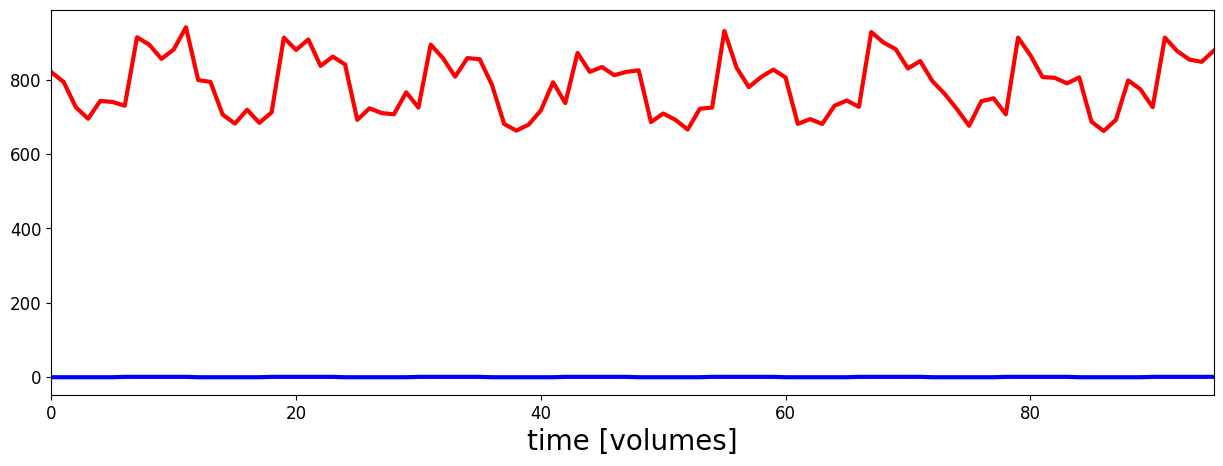

In [22]:
fig, ax = plt.subplots(1,1,figsize=(15, 5))
ax.plot(strongest_correlated, c = "red", lw=3)  #señal real del voxel
ax.plot(design_matrix[1,:], c = "blue" , lw=3) #patron esperado del estimulo
ax.set_xlim(0, acq_num-1)
ax.set_xlabel('time [volumes]', fontsize=20)
ax.tick_params(labelsize=12)
plt.show()

Lets normalise so we can visualize it better
One simple way of normalizing the data is min-max-scaling.


In [27]:
# Define the min-max scaling function
def scale(data):
    return (data - data.min()) / (data.max() - data.min())

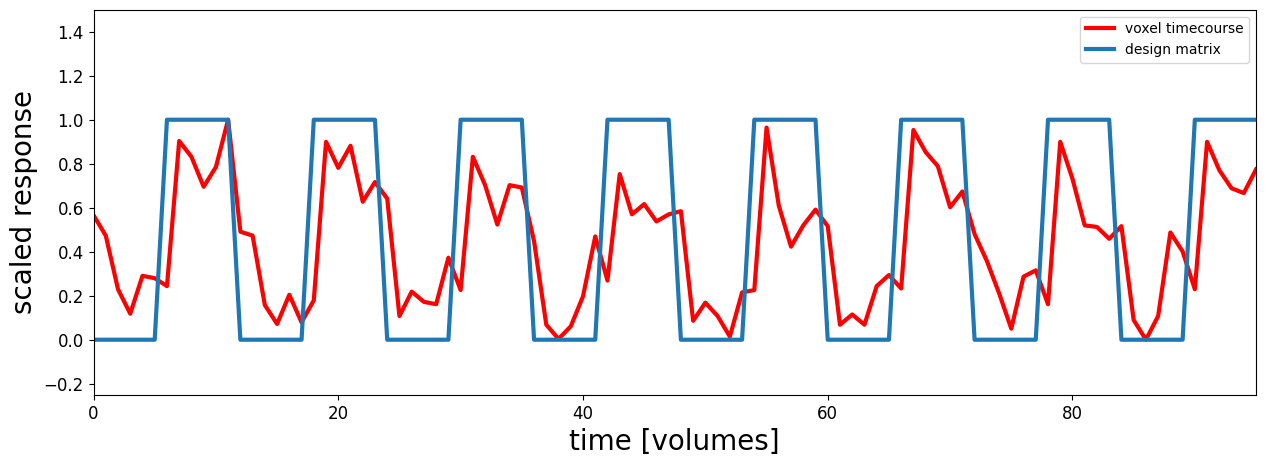

In [28]:
# Scale the voxel with the highest correlation
strongest_correlated_scaled = scale(data[c.argmax(),:])

# Create the plots
fig, (ax) = plt.subplots(1,1,figsize=(15, 5))
ax.plot(strongest_correlated_scaled, c = "red" , label='voxel timecourse', lw=3)
ax.plot(design_matrix[1,:], label='design matrix', lw=3)
ax.set_xlim(0, acq_num-1)
ax.set_ylim(-0.25, 1.5)
ax.set_xlabel('time [volumes]', fontsize=20)
ax.set_ylabel('scaled response', fontsize=20)
ax.tick_params(labelsize=12)
ax.legend()
plt.show()

##Correlation Images

How are voxels that correlate with our idealized timecourse distributed across the brain?

[]

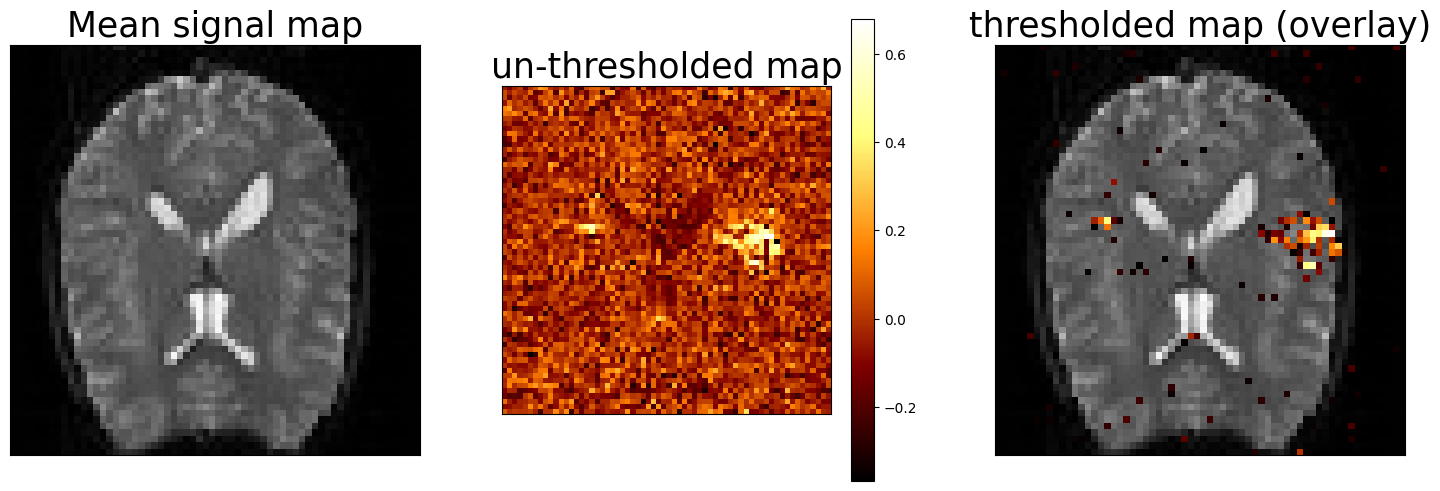

In [33]:
#Reshape the correlation vector for to see the mean signal map
corr = c.reshape(x_size, y_size)

#Select a threshold, we only see voxels with correlation coefficient β>0.2
map = corr.copy()
map[map < 0.2] = np.nan  #Nan para dejar espacios vacíos y sobreponer sin eliminar informacion

# Ok now lets visualize all the maps
fig, ax = plt.subplots(1,3,figsize=(18, 6))

#Mean Data
ax[0].imshow(mean_data, cmap='gray')    #Mean Data
ax[0].set_title('Mean signal map', fontsize=25)
ax[0].set_xticks([])
ax[0].set_yticks([])

#Visualizacion de coeficientes de correlacion
im1 = ax[1].imshow(corr,  cmap='afmhot')
ax[1].set_title('un-thresholded map', fontsize=25)
ax[1].set_xticks([])
ax[1].set_yticks([])
fig.colorbar(im1, ax=ax[1])

#Superposicion para Visualizacion
ax[2].imshow(mean_data, cmap='gray')
ax[2].imshow(map, cmap='afmhot')
ax[2].set_title('thresholded map (overlay)', fontsize=25)
ax[2].set_yticks([])
ax[2].set_xticks([])
ax[2].set_yticks([])


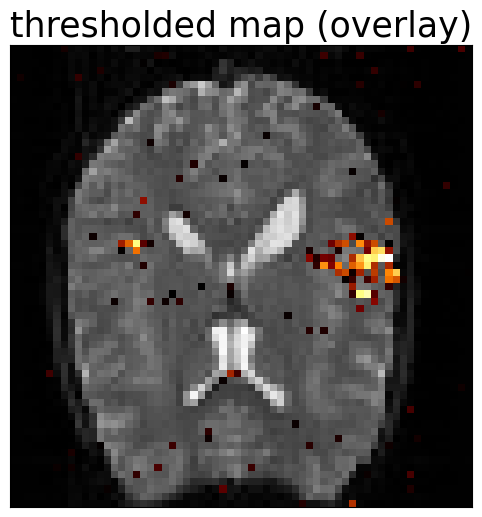

In [34]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(mean_data, cmap='gray')
ax.imshow(map, cmap='afmhot')
ax.set_title('Mapa de Correlacion', fontsize=25)
ax.set_xticks([])
ax.set_yticks([])

plt.show()

As we can see from the un-thresholded map the voxels with high correlations are not randomly distributed across the map but actually form a bigger cluster on the right side and a smaller cluster on the left side of the map. Finally we can see from the overlay that both clusters are located within the brain. The region were they are located is actually the auditory cortex which , as you may have guessed, is involved in processing auditory information.

>>El sonido simple activa ambos hemisferios de forma simétrica, ver dos clusters y no solo uno es una señal de coherencia biológica, no solo estadística. Ademas, estos están en posición lateral, no en el centro ni en los bordes externos del cráneo, lo que es consistente con dónde anatómicamente se ubica la corteza auditiva, en los lóbulos temporales, a los lados del cerebro.


>>Por otro lado, los puntitos rojos oscuros dispersos por todo el corte, fuera de los dos clusters, son correlaciones que superaron el umbral de 0.2 por puro azar, esperable estadísticamente en miles de vóxeles sin corrección múltiple, pero notablemente menos intensos (más oscuros = correlación más baja) y sin formar clusters coherentes, a diferencia de las zonas auditivas